# Machine Learning Assignment 2 — Student Outcome Radar

**M.Tech (AIML / DSE) · Work Integrated Learning Programmes Division, BITS Pilani**
Executed on **BITS Virtual Lab**.

**Problem.** Predict a student's academic outcome — `Dropout`, `Enrolled` or `Graduate` — from
enrolment-time information plus first- and second-semester academic records.
Three-class, single-label classification.

**Dataset.** *Predict Students' Dropout and Academic Success*, UCI ML Repository ID 697 —
4,424 instances × 36 features (assignment minimums: 500 instances, 12 features).

**Models.** Logistic Regression · Decision Tree · kNN · Gaussian Naive Bayes ·
Random Forest (ensemble) · Gradient Boosting (extra ensemble).

**Metrics.** Accuracy · AUC (one-vs-rest macro) · Precision · Recall · F1 · MCC — all
macro-averaged, because the middle `Enrolled` class is the minority and must not be averaged away.

> This notebook trains everything **in memory**. The deployed `*.joblib` artefacts and
> `metrics.json` are produced by `model/train_models.py`, which shares the exact same
> preprocessing and model definitions through `ml_core.py`.


## 1 · Setup

Shared definitions live in `ml_core.py` so training and the Streamlit app can never drift apart.

In [1]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

ROOT = Path.cwd().parent if Path.cwd().name == "model" else Path.cwd()
sys.path.insert(0, str(ROOT))

from ml_core import (
    SEED, TEST_FRACTION, TARGET, CLASS_ORDER,
    load_raw_dataset, split_column_groups, build_pipeline,
    evaluate, metrics_to_frame, model_zoo, METRIC_ORDER,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)

print("project root :", ROOT)
print("seed         :", SEED)
print("sklearn      :", __import__("sklearn").__version__)

project root : /Users/rishi.gudimetla/Desktop/007/ml-assignment2
seed         : 42
sklearn      : 1.9.0


## 2 · Load the dataset

The raw UCI file is semicolon-separated and its headers carry stray quotes/tabs, which `ml_core.tidy_column` cleans.

In [2]:
data = load_raw_dataset()

print("shape            :", data.shape)
print("features         :", data.shape[1] - 1)
print("missing values   :", int(data.isna().sum().sum()))
print("duplicated rows  :", int(data.duplicated().sum()))
data.head()

shape            : (4424, 37)
features         : 36
missing values   : 0
duplicated rows  : 0


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


          instances   share
Target                     
Dropout        1421  32.12%
Enrolled        794  17.95%
Graduate       2209  49.93%

imbalance ratio : 2.78 : 1
majority-class baseline accuracy : 49.93%


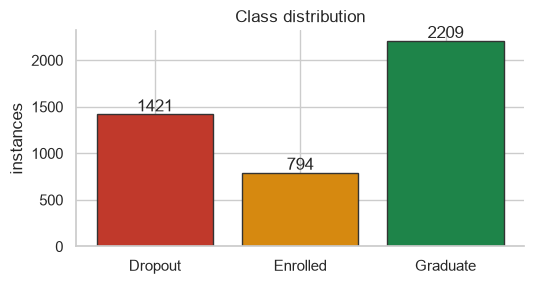

In [3]:
counts = data[TARGET].value_counts().reindex(CLASS_ORDER)
summary = pd.DataFrame({"instances": counts, "share": (counts / len(data)).map("{:.2%}".format)})
print(summary)
print(f"\nimbalance ratio : {counts.max() / counts.min():.2f} : 1")
print(f"majority-class baseline accuracy : {counts.max() / len(data):.2%}")

fig, ax = plt.subplots(figsize=(5.5, 3))
ax.bar(counts.index, counts.values, color=["#c0392b", "#d68910", "#1e8449"], edgecolor="#333")
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha="center")
ax.set_ylabel("instances"); ax.set_title("Class distribution")
sns.despine(); plt.tight_layout(); plt.show()

### Assignment requirement check

In [4]:
checks = pd.DataFrame(
    [
        ["Minimum feature size", 12, data.shape[1] - 1, data.shape[1] - 1 >= 12],
        ["Minimum instance size", 500, data.shape[0], data.shape[0] >= 500],
        ["Public repository (UCI/Kaggle)", "yes", "UCI ID 697", True],
    ],
    columns=["requirement", "required", "actual", "satisfied"],
)
checks

,requirement,required,actual,satisfied
0,Minimum feature size,12,36,True
1,Minimum instance size,500,4424,True
2,Public repository (UCI/Kaggle),yes,UCI ID 697,True


## 3 · Stratified train / test split

80 / 20, stratified on the target, fixed seed. The test split is the file the Streamlit app scores.

In [5]:
X, y = data.drop(columns=[TARGET]), data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_FRACTION, stratify=y, random_state=SEED
)
print(f"train : {X_train.shape[0]} rows")
print(f"test  : {X_test.shape[0]} rows")
pd.DataFrame({
    "train share": y_train.value_counts(normalize=True).reindex(CLASS_ORDER),
    "test share":  y_test.value_counts(normalize=True).reindex(CLASS_ORDER),
}).style.format("{:.4f}")

train : 3539 rows
test  : 885 rows


,train share,test share
Target,,
Dropout,0.3213,0.3209
Enrolled,0.1794,0.1797
Graduate,0.4993,0.4994


## 4 · Pre-processing

Three column families, handled differently on purpose:

| family | handling | why |
|---|---|---|
| nominal codes (`Course`, `Application mode`, parental qualification/occupation, …) | one-hot, `handle_unknown='ignore'` | the integers are labels, not magnitudes |
| continuous / ordinal (grades, curricular units, macro-economics, age) | `StandardScaler` | required by Logistic Regression and kNN |
| binary flags (`Debtor`, `Scholarship holder`, …) | passthrough | already 0/1 |

Everything is wrapped in a `Pipeline`, so the encoder and scaler are fitted **inside each CV
fold** — no leakage from the validation data into preprocessing.

In [6]:
categorical, numeric, binary = split_column_groups(X_train)
print(f"one-hot encoded : {len(categorical)}  -> {categorical}")
print(f"standard scaled : {len(numeric)}")
print(f"passthrough     : {len(binary)}  -> {binary}")

probe = build_pipeline("Logistic Regression", X_train).named_steps["prep"].fit(X_train)
print("\nexpanded dimensionality after encoding :", probe.transform(X_train.head(5)).shape[1])

one-hot encoded : 9  -> ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
standard scaled : 19
passthrough     : 8  -> ['Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']



expanded dimensionality after encoding : 236


## 5 · Train and tune all six models

`GridSearchCV`, 5-fold `StratifiedKFold`, scoring `f1_macro` (not accuracy — the minority class
must count). `class_weight='balanced'` / `'balanced_subsample'` is used wherever the estimator
supports it.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
zoo = model_zoo()

fitted, results, tuned, cv_score = {}, {}, {}, {}

for name, spec in zoo.items():
    t0 = time.perf_counter()
    search = GridSearchCV(build_pipeline(name, X_train), spec["grid"],
                          scoring="f1_macro", cv=cv, n_jobs=-1, refit=True)
    search.fit(X_train, y_train)

    fitted[name] = search.best_estimator_
    scored = evaluate(search.best_estimator_, X_test, y_test, CLASS_ORDER)
    results[name] = scored
    tuned[name] = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    cv_score[name] = search.best_score_

    print(f"{name:38} cv={search.best_score_:.4f}  acc={scored['Accuracy']:.4f}  "
          f"f1={scored['F1']:.4f}  mcc={scored['MCC']:.4f}  ({time.perf_counter()-t0:.1f}s)")
    print(f"{'':38} best params: {tuned[name]}")

Logistic Regression                    cv=0.7125  acc=0.7322  f1=0.6940  mcc=0.5856  (3.3s)
                                       best params: {'C': 0.05}


Decision Tree                          cv=0.6700  acc=0.6486  f1=0.6314  mcc=0.4929  (0.7s)
                                       best params: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 1}


kNN                                    cv=0.6222  acc=0.6938  f1=0.6050  mcc=0.4876  (1.3s)
                                       best params: {'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
Naive Bayes                            cv=0.6323  acc=0.6814  f1=0.6009  mcc=0.4725  (0.1s)
                                       best params: {'var_smoothing': 0.1}


/Users/rishi.gudimetla/Desktop/007/ml-assignment2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rishi.gudimetla/Desktop/007/ml-assignment2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rishi.gudimetla/Desktop/007/ml-assignment2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib 

/Users/rishi.gudimetla/Desktop/007/ml-assignment2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rishi.gudimetla/Desktop/007/ml-assignment2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rishi.gudimetla/Desktop/007/ml-assignment2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib 

/Users/rishi.gudimetla/Desktop/007/ml-assignment2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


/Users/rishi.gudimetla/Desktop/007/ml-assignment2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rishi.gudimetla/Desktop/007/ml-assignment2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rishi.gudimetla/Desktop/007/ml-assignment2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib 

/Users/rishi.gudimetla/Desktop/007/ml-assignment2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rishi.gudimetla/Desktop/007/ml-assignment2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rishi.gudimetla/Desktop/007/ml-assignment2/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib 

Random Forest (Ensemble)               cv=0.7154  acc=0.7684  f1=0.7171  mcc=0.6240  (13.1s)
                                       best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3}


Gradient Boosting (Ensemble, extra)    cv=0.7128  acc=0.7582  f1=0.6852  mcc=0.6000  (11.9s)
                                       best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


## 6 · Comparison table — the six required metrics for every model

In [8]:
table = metrics_to_frame(results)
display(table.style.format("{:.4f}").background_gradient(cmap="YlGn", axis=0))

winner = table["F1"].idxmax()
print(f"Best macro-F1 : {winner} ({table.loc[winner, 'F1']:.4f})")
print(f"Best accuracy : {table['Accuracy'].idxmax()} ({table['Accuracy'].max():.4f})")
print(f"Best AUC      : {table['AUC'].idxmax()} ({table['AUC'].max():.4f})")
print(f"Best MCC      : {table['MCC'].idxmax()} ({table['MCC'].max():.4f})")

,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.7322,0.8859,0.7039,0.7062,0.6940,0.5856
Decision Tree,0.6486,0.8240,0.6660,0.6580,0.6314,0.4929
kNN,0.6938,0.7979,0.6294,0.5978,0.6050,0.4876
Naive Bayes,0.6814,0.8163,0.6200,0.5948,0.6009,0.4725
Random Forest (Ensemble),0.7684,0.8876,0.7203,0.7164,0.7171,0.6240
"Gradient Boosting (Ensemble, extra)",0.7582,0.8820,0.6977,0.6783,0.6852,0.6000


Best macro-F1 : Random Forest (Ensemble) (0.7171)
Best accuracy : Random Forest (Ensemble) (0.7684)
Best AUC      : Random Forest (Ensemble) (0.8876)
Best MCC      : Random Forest (Ensemble) (0.6240)


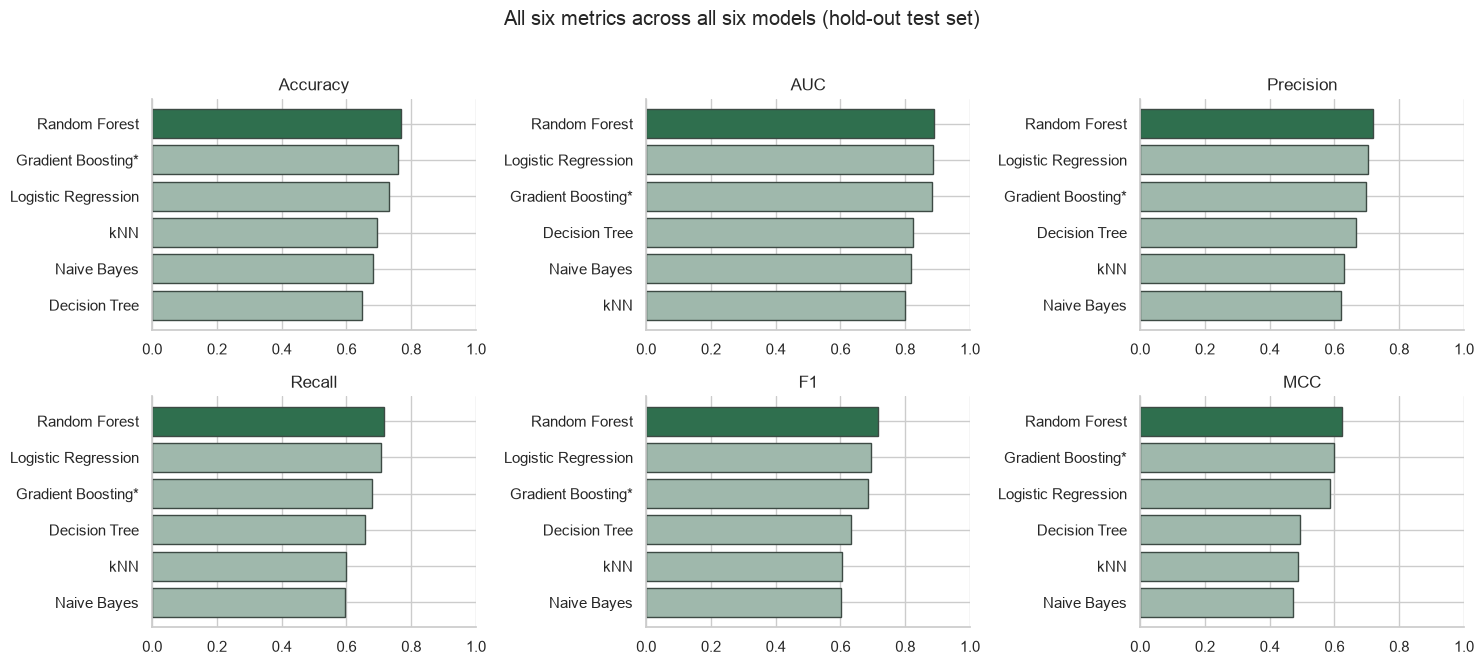

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.5))
for ax, metric in zip(axes.ravel(), METRIC_ORDER):
    ordered = table[metric].sort_values()
    colors = ["#2f6f4e" if i == winner else "#9fb8ac" for i in ordered.index]
    ax.barh([i.replace(" (Ensemble, extra)", "*").replace(" (Ensemble)", "") for i in ordered.index],
            ordered.values, color=colors, edgecolor="#3d4a44")
    ax.set_title(metric); ax.set_xlim(0, 1)
plt.suptitle("All six metrics across all six models (hold-out test set)", y=1.02)
sns.despine(); plt.tight_layout(); plt.show()

## 7 · Confusion matrices and per-class behaviour

Where each model actually makes its mistakes.

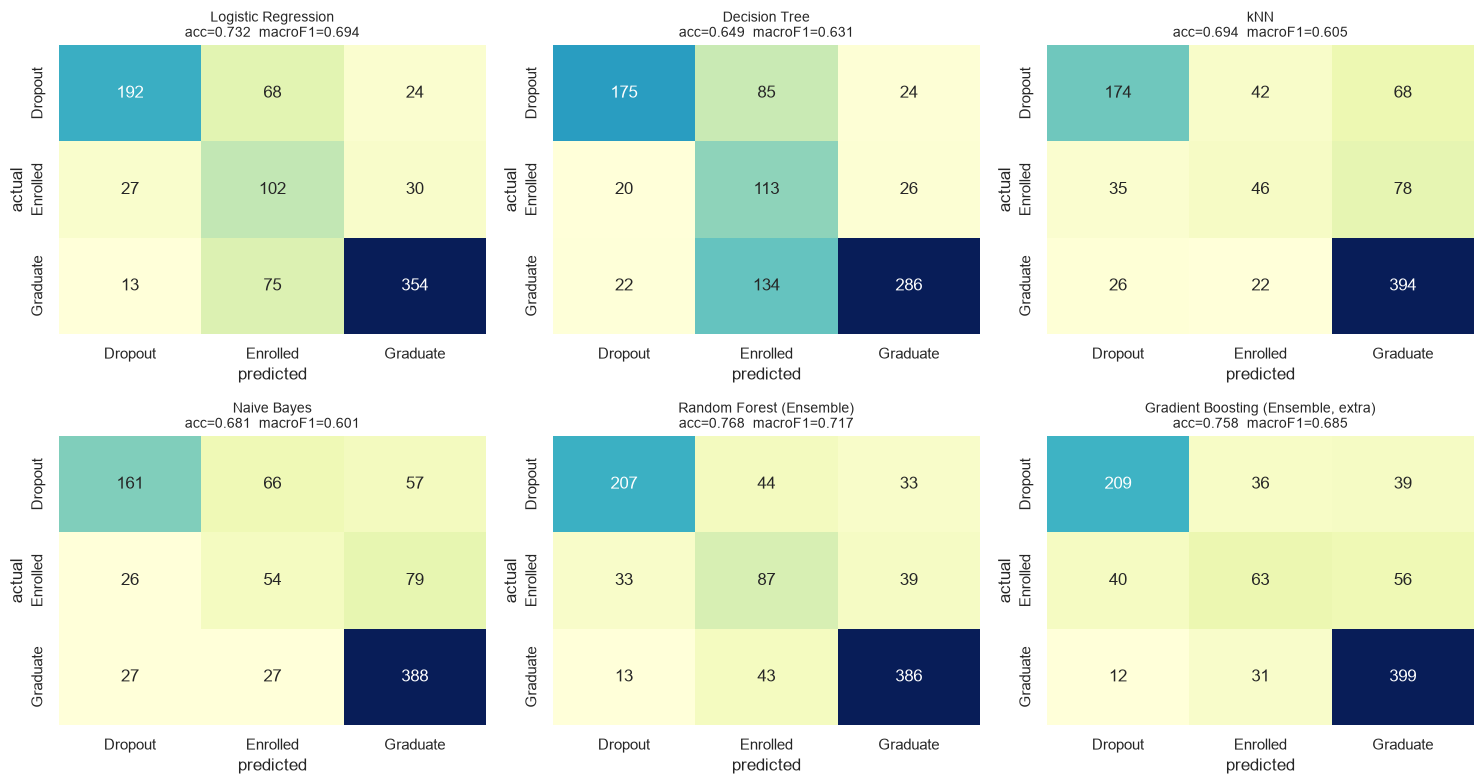

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, scored) in zip(axes.ravel(), results.items()):
    sns.heatmap(np.array(scored["confusion_matrix"]), annot=True, fmt="d", cmap="YlGnBu",
                cbar=False, xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
    ax.set_title(f"{name}\nacc={scored['Accuracy']:.3f}  macroF1={scored['F1']:.3f}", fontsize=10)
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout(); plt.show()

In [11]:
per_class = pd.DataFrame({
    name: {cls: scored["per_class"][cls]["f1-score"] for cls in CLASS_ORDER}
    for name, scored in results.items()
}).T
print("Per-class F1 - the Enrolled column is every model's weak spot:")
display(per_class.style.format("{:.4f}").background_gradient(cmap="YlGn", axis=None))
print(results[winner]["report_text"])

Per-class F1 - the Enrolled column is every model's weak spot:


,Dropout,Enrolled,Graduate
Logistic Regression,0.7442,0.5050,0.8329
Decision Tree,0.6986,0.4603,0.7352
kNN,0.6705,0.3420,0.8024
Naive Bayes,0.6466,0.3529,0.8033
Random Forest (Ensemble),0.7709,0.5225,0.8578
"Gradient Boosting (Ensemble, extra)",0.7670,0.4360,0.8526


              precision    recall  f1-score   support

     Dropout     0.8182    0.7289    0.7709       284
    Enrolled     0.5000    0.5472    0.5225       159
    Graduate     0.8428    0.8733    0.8578       442

    accuracy                         0.7684       885
   macro avg     0.7203    0.7164    0.7171       885
weighted avg     0.7733    0.7684    0.7697       885



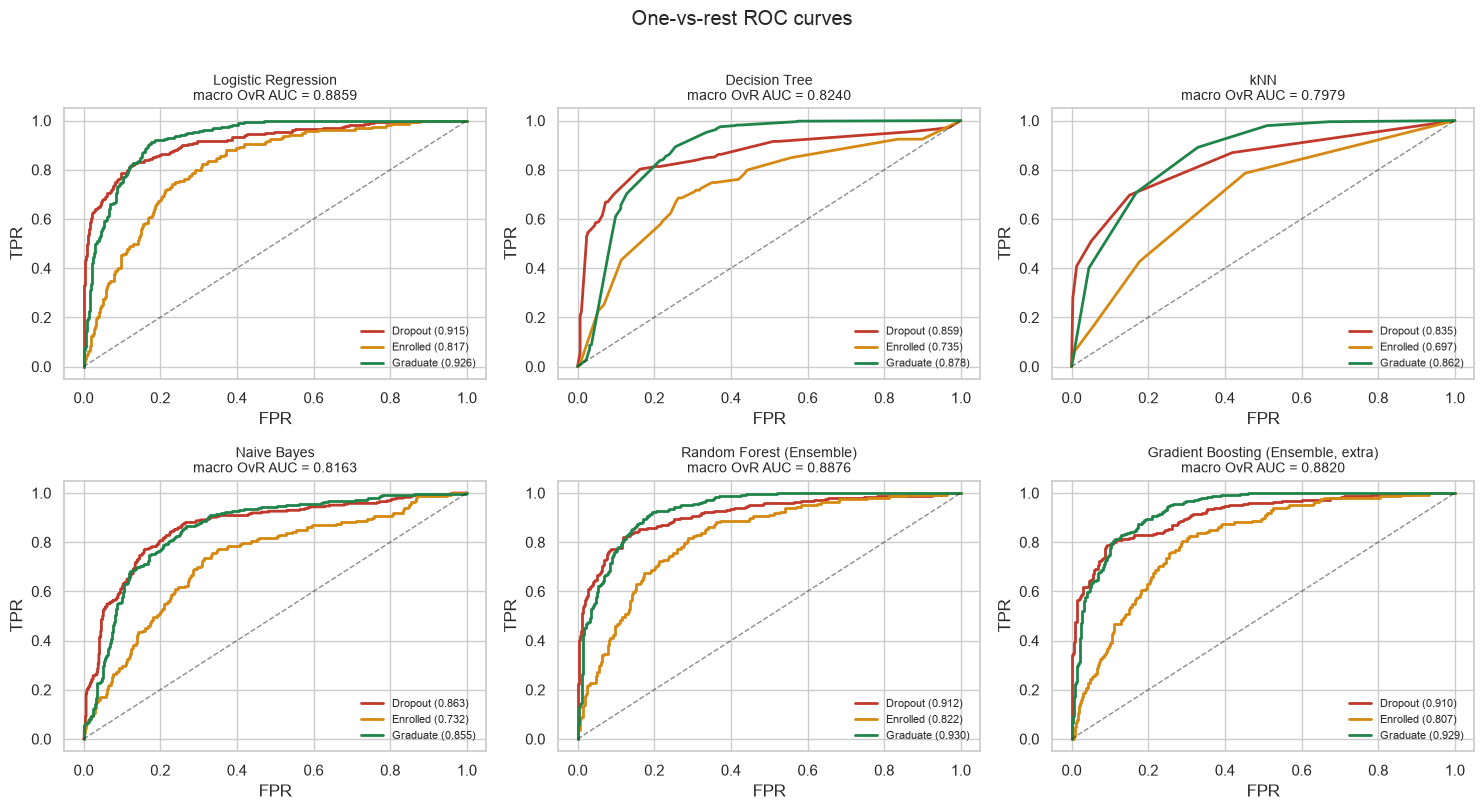

In [12]:
from sklearn.metrics import roc_curve, auc as auc_of_curve
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
palette = {"Dropout": "#c0392b", "Enrolled": "#d68910", "Graduate": "#1e8449"}
for ax, (name, model) in zip(axes.ravel(), fitted.items()):
    proba = model.predict_proba(X_test)
    y_bin = label_binarize(y_test, classes=list(model.classes_))
    for i, cls in enumerate(model.classes_):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        ax.plot(fpr, tpr, color=palette[cls], lw=2, label=f"{cls} ({auc_of_curve(fpr, tpr):.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=.5)
    ax.set_title(f"{name}\nmacro OvR AUC = {results[name]['AUC']:.4f}", fontsize=10)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=8, loc="lower right", frameon=False)
plt.suptitle("One-vs-rest ROC curves", y=1.01)
plt.tight_layout(); plt.show()

## 8 · Which features drive the prediction?

Random Forest impurity importances, aggregated back to the original columns.

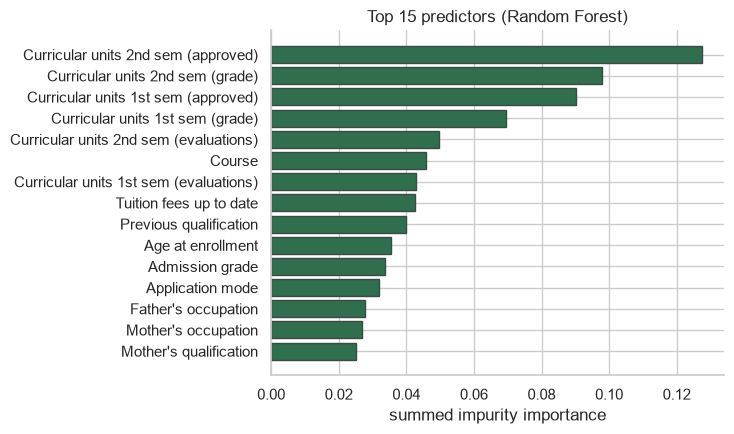

Curricular units 2nd sem (approved)       0.1276
Curricular units 2nd sem (grade)          0.0980
Curricular units 1st sem (approved)       0.0903
Curricular units 1st sem (grade)          0.0695
Curricular units 2nd sem (evaluations)    0.0495
Course                                    0.0458
Curricular units 1st sem (evaluations)    0.0427
Tuition fees up to date                   0.0427
Previous qualification                    0.0399
Age at enrollment                         0.0356
Admission grade                           0.0337
Application mode                          0.0319
Father's occupation                       0.0278
Mother's occupation                       0.0269
Mother's qualification                    0.0251
dtype: float64

In [13]:
rf = fitted["Random Forest (Ensemble)"]
names = rf.named_steps["prep"].get_feature_names_out()
importance = pd.Series(rf.named_steps["clf"].feature_importances_, index=names)

# collapse one-hot dummies back onto their source column
def source_column(f):
    for c in categorical:
        if f.startswith(c):
            return c
    return f

top = importance.groupby(source_column).sum().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.barh(top.index[::-1], top.values[::-1], color="#2f6f4e", edgecolor="#3d4a44")
ax.set_xlabel("summed impurity importance"); ax.set_title("Top 15 predictors (Random Forest)")
sns.despine(); plt.tight_layout(); plt.show()
top.round(4)

## 9 · Observations and conclusion

| Model | Observation |
|---|---|
| **Logistic Regression** | Strongest non-ensemble model and almost level with the Random Forest on AUC, so the class boundaries are largely linear once the semester-approval features are scaled. `class_weight='balanced'` lifts `Enrolled` recall but its precision stays low, i.e. it over-predicts the middle class. Cheapest to train, easiest to explain. |
| **Decision Tree** | Lowest accuracy of the six; CV had to prune it (`max_depth=6`), confirming a full tree over-fits the one-hot parental-background columns. Highest `Enrolled` recall of all models but at very low precision, and it sacrifices `Graduate` recall to get there. High variance — the building block the ensembles average away. |
| **kNN** | Decent accuracy but the worst AUC. One-hot encoding pushes the space to 236 dimensions where neighbourhoods stop being meaningful, and with no `class_weight` option it collapses onto the majority `Graduate` class. Slowest at inference (lazy learner). |
| **Naive Bayes** | Lowest macro-F1 and MCC. The conditional-independence assumption is plainly violated — 1st/2nd-semester enrolled, approved and grade columns are strongly correlated, so evidence is double-counted and posteriors are over-confident. Still a useful sub-second baseline, and its AUC beats kNN. |
| **Random Forest (Ensemble)** | **Winner on all six metrics.** Bagging removes the single tree's variance while `balanced_subsample` keeps the minority class visible: the only model holding `Enrolled` precision at 0.50 while still recalling over half of them, and best on both `Dropout` and `Graduate` recall. Costs the largest artefact and the longest training time. |
| **Gradient Boosting (extra)** | Close to the Random Forest on accuracy and AUC and the best `Graduate` recall, but without class weighting it gives up the minority class, so macro-F1 falls behind. Shows that on this dataset *ensembling* delivers the gain and *imbalance handling* separates the two ensembles. |

**Conclusion.** The Random Forest is the model to deploy: it tops every metric, its 5-fold CV
score matches its hold-out score (so the win is not a lucky split), and it degrades most
gracefully on the hard middle class. Practically, `Dropout` vs `Graduate` is nearly solved,
while `Enrolled` should be treated as "needs a human look" rather than a confident prediction.

The fitted artefacts, `metrics.json` and the two CSV splits are written by
`model/train_models.py`; `app.py` loads those artefacts and recomputes these numbers live.

In [14]:
print("Notebook run complete.")
print(f"Winner: {winner}")
display(table.round(4))

Notebook run complete.
Winner: Random Forest (Ensemble)


,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.7322,0.8859,0.7039,0.7062,0.6940,0.5856
Decision Tree,0.6486,0.8240,0.6660,0.6580,0.6314,0.4929
kNN,0.6938,0.7979,0.6294,0.5978,0.6050,0.4876
Naive Bayes,0.6814,0.8163,0.6200,0.5948,0.6009,0.4725
Random Forest (Ensemble),0.7684,0.8876,0.7203,0.7164,0.7171,0.6240
"Gradient Boosting (Ensemble, extra)",0.7582,0.8820,0.6977,0.6783,0.6852,0.6000
